In [14]:
import sys
import os
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))

In [15]:
from utils.dataloader import get_dataloader, get_transforms

BASE_DIR = os.path.abspath("..")

train_path = os.path.join(BASE_DIR, "data/WLBisindo/split/train")
val_path   = os.path.join(BASE_DIR, "data/WLBisindo/split/val")
test_path  = os.path.join(BASE_DIR, "data/WLBisindo/split/test")

train_transform, val_transform = get_transforms()

train_loader = get_dataloader(train_path, transform=train_transform)
val_loader   = get_dataloader(val_path, shuffle=False, transform=val_transform)
test_loader  = get_dataloader(test_path, shuffle=False, transform=val_transform)

In [16]:
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

log_dir = os.path.join(BASE_DIR, "outputs/logs/mobile_net", f"run_{timestamp}")
os.makedirs(log_dir, exist_ok=True)

writer = SummaryWriter(log_dir)

In [17]:
log_file = os.path.join(log_dir, "log.txt")

def log_message(msg):
    print(msg)
    with open(log_file, "a") as f:
        f.write(msg + "\n")

In [18]:
from models.mobile_net import MobileNetTransformer

NUM_CLASSES = len(train_loader.dataset.label_map)

model = MobileNetTransformer(num_classes=NUM_CLASSES)

In [19]:
import torch
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# freeze CNN
for param in model.encoder.features.parameters():
    param.requires_grad = False

# unfreeze last block
for param in model.encoder.features[-1].parameters():
    param.requires_grad = True

In [20]:
labels = train_loader.dataset.labels

class_counts = Counter(labels)
total = sum(class_counts.values())

weights = [total / class_counts[i] for i in range(len(class_counts))]
weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=weights)

In [21]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-5,   # lebih kecil dari CNN-LSTM
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

In [22]:
EPOCHS = 10
patience = 3
counter = 0
best_val_loss = float("inf")

import json

config = {
    "model": "MobileNetTransformer",
    "epochs": 10,
    "lr": 3e-5,
    "weight_decay": 1e-5,
    "batch_size": train_loader.batch_size,
    "num_classes": NUM_CLASSES,
    "transformer_layers": 2
}

with open(os.path.join(log_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=4)

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ===== TRAIN =====
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc="Training", leave=False)

    for x, y in train_bar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

        # update progress bar
        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for x, y in val_bar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

            # update progress bar
            val_bar.set_postfix({
                "loss": f"{loss.item():.4f}"
            })

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # ===== LOGGING =====
    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)

    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)

    writer.add_scalar("Overfitting/gap", train_acc - val_acc, epoch)

    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar("LR", current_lr, epoch)

    for name, param in model.named_parameters():
        writer.add_histogram(f"Weights/{name}", param, epoch)

        if param.grad is not None:
            writer.add_histogram(f"Gradients/{name}", param.grad, epoch)

    log_message(f"Epoch {epoch+1}/{EPOCHS}")
    log_message(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    log_message(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")
    log_message(f"LR: {current_lr}")
    log_message("-" * 40)

    # ===== SCHEDULER =====
    scheduler.step(val_loss)


    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), os.path.join(log_dir, "best_model.pth"))
        log_message("Best model saved!")

    else:
        counter += 1
        log_message(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            log_message("Early stopping triggered!")
            break


# SAVE LAST MODEL
torch.save(model.state_dict(), os.path.join(log_dir, "last_model.pth"))


Epoch 1/10


Epoch 1/10
Train Loss: 3.6114 | Acc: 0.0370
Val   Loss: 3.3606 | Acc: 0.0989
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 2/10


Epoch 2/10
Train Loss: 3.3249 | Acc: 0.0963
Val   Loss: 3.0578 | Acc: 0.1374
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 3/10


Epoch 3/10
Train Loss: 2.9890 | Acc: 0.1579
Val   Loss: 2.7414 | Acc: 0.1648
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 4/10


Epoch 4/10
Train Loss: 2.5938 | Acc: 0.2452
Val   Loss: 2.3930 | Acc: 0.3132
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 5/10


...

Epoch 6/10
Train Loss: 1.9813 | Acc: 0.4076
Val   Loss: 1.8344 | Acc: 0.4341
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 7/10


Epoch 7/10
Train Loss: 1.6421 | Acc: 0.4882
Val   Loss: 1.7164 | Acc: 0.4615
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 8/10


Epoch 8/10
Train Loss: 1.4861 | Acc: 0.5454
Val   Loss: 1.4515 | Acc: 0.5440
LR: 3e-05
----------------------------------------
Best model saved!

Epoch 9/10


Epoch 9/10
Train Loss: 1.3579 | Acc: 0.5778
Val   Loss: 1.4586 | Acc: 0.5714
LR: 3e-05
----------------------------------------
EarlyStopping counter: 1/3

Epoch 10/10


Epoch 10/10
Train Loss: 1.2448 | Acc: 0.6327
Val   Loss: 1.2669 | Acc: 0.6538
LR: 3e-05
----------------------------------------
Best model saved!


In [23]:
import os
from utils.evaluate import evaluate

report_path = os.path.join(log_dir, "evaluation.json")

metrics = evaluate(
    model,
    test_loader,
    device,
    save_path=report_path,
    model_name="CNNResNetLSTM"
)

Evaluation Metrics:
accuracy: 0.6457
precision: 0.7301
recall: 0.6438
f1: 0.6409
hamming_loss: 0.3543
Experiment logged to: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/metrics\experiments.csv


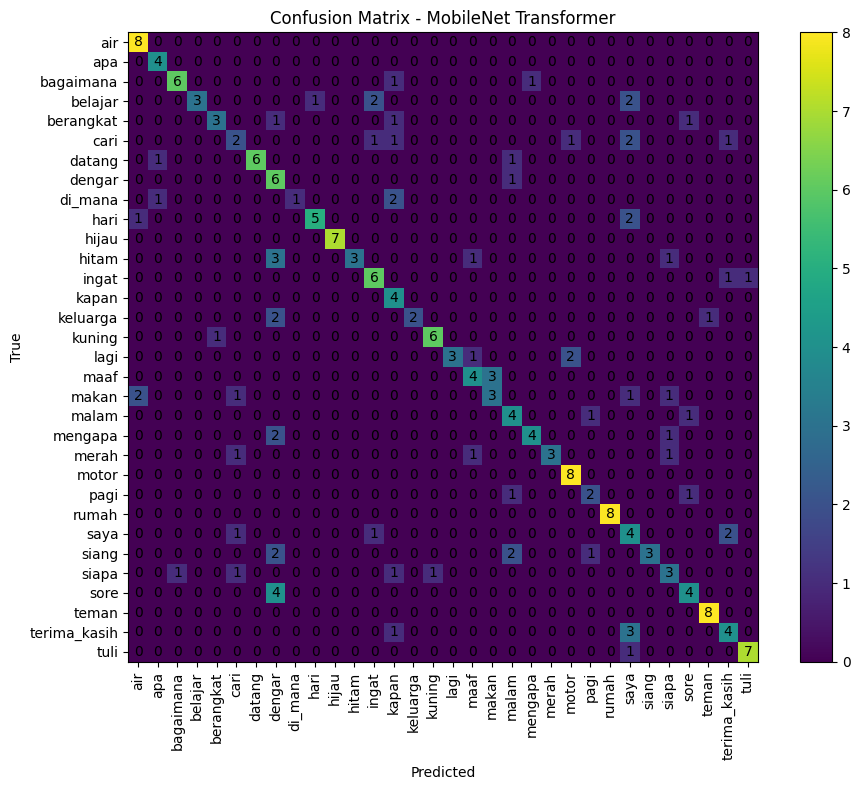

Confusion matrix saved to: D:\Softwares\AnacondaProjects\GestureSequenceCNN\outputs/logs/mobile_net\run_20260409_113840\confusion_matrix.png


In [24]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix - MobileNet Transformer")
plt.colorbar()

labels = list(train_loader.dataset.label_map.keys())

plt.xticks(np.arange(len(labels)), labels, rotation=90)
plt.yticks(np.arange(len(labels)), labels)

plt.xlabel("Predicted")
plt.ylabel("True")

# Tambahin angka di tiap cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.tight_layout()

# save
cm_path = os.path.join(log_dir, "confusion_matrix.png")
plt.savefig(cm_path)

plt.show()

print("Confusion matrix saved to:", cm_path)